# 🎵 Spotify Tracks Dataset — ETL Pipeline & EDA

> **114,000 tracks · 114 genres · 21 features**

**Tools:** `pandas` · `numpy` · `matplotlib` · `seaborn`  
**Goal:** Clean, transform, analyse and export data for Power BI visualisation  
**Project Type:** Internship Resume Project

---

## 📋 Table of Contents
| # | Section |
|---|---|
| 1 | [Setup & Imports](#1-setup) |
| 2 | [EXTRACT — Load Raw Data](#2-extract) |
| 3 | [EXPLORE — Initial Data Profiling](#3-explore) |
| 4 | [TRANSFORM — Clean & Engineer Features](#4-transform) |
| 5 | [LOAD — Aggregate & Export for Power BI](#5-load) |
| 6 | [EDA — Popularity Analysis](#6-popularity) |
| 7 | [EDA — Genre Analysis](#7-genre) |
| 8 | [EDA — Audio Feature Distributions](#8-features) |
| 9 | [EDA — Correlation & Heatmap](#9-correlation) |
| 10 | [EDA — Artist Analysis](#10-artists) |
| 11 | [EDA — Tempo, Key & Mode](#11-musical) |
| 12 | [EDA — Explicit Content Analysis](#12-explicit) |
| 13 | [Key Insights Summary](#13-insights) |

---
## 1. Setup & Imports <a id='1-setup'></a>

In [2]:
# ── Core libraries ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Plot theme — dark, clean, presentation-ready ─────────────────────────────
sns.set_theme(style='darkgrid')
plt.rcParams.update({
    'figure.dpi'        : 120,
    'figure.facecolor'  : '#111827',
    'axes.facecolor'    : '#1f2937',
    'axes.labelcolor'   : '#e5e7eb',
    'axes.titlecolor'   : '#f9fafb',
    'axes.edgecolor'    : '#374151',
    'xtick.color'       : '#9ca3af',
    'ytick.color'       : '#9ca3af',
    'text.color'        : '#e5e7eb',
    'grid.color'        : '#374151',
    'grid.linewidth'    : 0.6,
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
    'legend.facecolor'  : '#1f2937',
    'legend.edgecolor'  : '#374151',
    'legend.labelcolor' : '#e5e7eb',
})

# ── Colour palette ────────────────────────────────────────────────────────────
SPOTIFY_GREEN  = '#1DB954'
PALETTE        = ['#1DB954','#ff6b6b','#4ecdc4','#ffe66d','#a8e6cf','#ff8b94',
                  '#c7ceea','#ffd3b6','#dcedc1','#ffaaa5']
PALETTE_CONT   = 'YlGn'

print('✅ Libraries loaded')
print(f'   pandas     {pd.__version__}')
print(f'   numpy      {np.__version__}')
import matplotlib; print(f'   matplotlib {matplotlib.__version__}')
print(f'   seaborn    {sns.__version__}')

✅ Libraries loaded
   pandas     2.3.3
   numpy      2.3.5
   matplotlib 3.10.6
   seaborn    0.13.2


---
## 2. EXTRACT — Load Raw Data <a id='2-extract'></a>

### Dataset Schema
| Column | Type | Description |
|---|---|---|
| track_id | string | Spotify unique track ID |
| artists | string | Artist name(s), semicolon-separated |
| album_name | string | Album name |
| track_name | string | Song title |
| popularity | int (0–100) | Spotify popularity score |
| duration_ms | int | Track length in milliseconds |
| explicit | bool | Whether track has explicit lyrics |
| danceability | float (0–1) | How suitable for dancing |
| energy | float (0–1) | Perceptual intensity & activity |
| key | int (0–11) | Pitch class (0=C, 1=C#, …, 11=B) |
| loudness | float (dB) | Average loudness |
| mode | int (0/1) | Minor (0) or Major (1) |
| speechiness | float (0–1) | Presence of spoken words |
| acousticness | float (0–1) | Whether track is acoustic |
| instrumentalness | float (0–1) | Predicts no vocals |
| liveness | float (0–1) | Probability of live recording |
| valence | float (0–1) | Musical positiveness |
| tempo | float | BPM |
| time_signature | int | Beats per bar |
| track_genre | string | Genre label |

In [4]:
from pathlib import Path

# -- Load the dataset ----------------------------------------------------------
DATA_PATHS = [Path('csv/dataset.csv'), Path('dataset.csv')]
FILE_PATH = next((path for path in DATA_PATHS if path.exists()), None)

if FILE_PATH is None:
    raise FileNotFoundError("Could not find dataset.csv. Expected it in ./csv/dataset.csv or ./dataset.csv")

df = pd.read_csv(FILE_PATH, index_col=0)   # first col is a row index

print('✅ Loaded successfully')
print(f'   File    : {FILE_PATH}')
print(f'   Rows    : {len(df):,}')
print(f'   Columns : {df.shape[1]}')
print(f'   Memory  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head()

✅ Loaded successfully
   File    : csv\dataset.csv
   Rows    : 114,000
   Columns : 20
   Memory  : 52.1 MB


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


---
## 3. EXPLORE — Initial Data Profiling <a id='3-explore'></a>

In [3]:
# ── 3.1  Data types & nulls ───────────────────────────────────────────────────
print('=== DATA TYPES & NULL COUNTS ===')
profile = pd.DataFrame({
    'dtype'     : df.dtypes,
    'null_count': df.isnull().sum(),
    'null_pct'  : (df.isnull().sum() / len(df) * 100).round(2),
    'unique'    : df.nunique(),
})
print(profile.to_string())

=== DATA TYPES & NULL COUNTS ===
                    dtype  null_count  null_pct  unique
track_id           object           0       0.0   89741
artists            object           1       0.0   31437
album_name         object           1       0.0   46589
track_name         object           1       0.0   73608
popularity          int64           0       0.0     101
duration_ms         int64           0       0.0   50697
explicit             bool           0       0.0       2
danceability      float64           0       0.0    1174
energy            float64           0       0.0    2083
key                 int64           0       0.0      12
loudness          float64           0       0.0   19480
mode                int64           0       0.0       2
speechiness       float64           0       0.0    1489
acousticness      float64           0       0.0    5061
instrumentalness  float64           0       0.0    5346
liveness          float64           0       0.0    1722
valence        

In [4]:
# ── 3.2  Descriptive statistics ───────────────────────────────────────────────
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
track_id,114000,89741,6S3JlDAGk3uu3NtZbPnuhS,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
artists,113999,31437,The Beatles,279,NaN,NaN,NaN,NaN,NaN,NaN,NaN
album_name,113999,46589,Alternative Christmas 2022,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_name,113999,73608,Run Rudolph Run,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,114000.0,NaN,NaN,NaN,33.238535,22.305078,0.0,17.0,35.0,50.0,100.0
duration_ms,114000.0,NaN,NaN,NaN,228029.153114,107297.712645,0.0,174066.0,212906.0,261506.0,5237295.0
explicit,114000,2,False,104253,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,114000.0,NaN,NaN,NaN,0.5668,0.173542,0.0,0.456,0.58,0.695,0.985
energy,114000.0,NaN,NaN,NaN,0.641383,0.251529,0.0,0.472,0.685,0.854,1.0
key,114000.0,NaN,NaN,NaN,5.30914,3.559987,0.0,2.0,5.0,8.0,11.0


In [5]:
# ── 3.3  Categorical overview ─────────────────────────────────────────────────
print(f'Unique genres  : {df["track_genre"].nunique()}')
print(f'Unique artists : {df["artists"].nunique()}')
print(f'Unique albums  : {df["album_name"].nunique()}')
print(f'Unique tracks  : {df["track_name"].nunique()}')
print(f'Duplicate track_ids   : {df["track_id"].duplicated().sum():,}')
print(f'Duplicate name+artist : {df.duplicated(subset=["track_name","artists"]).sum():,}')
print(f'\nTop 10 Genres (by count):')
print(df['track_genre'].value_counts().head(10))

Unique genres  : 114
Unique artists : 31437
Unique albums  : 46589
Unique tracks  : 73608
Duplicate track_ids   : 24,259
Duplicate name+artist : 32,656

Top 10 Genres (by count):
track_genre
acoustic             1000
punk-rock            1000
progressive-house    1000
power-pop            1000
pop                  1000
pop-film             1000
piano                1000
party                1000
pagode               1000
opera                1000
Name: count, dtype: int64


---
## 4. TRANSFORM — Clean & Engineer Features <a id='4-transform'></a>

In [6]:
# ── 4.1  Drop rows with null artist / track_name / album_name ────────────────
before = len(df)
df.dropna(subset=['artists', 'track_name', 'album_name'], inplace=True)
print(f'Null rows dropped : {before - len(df)}')

Null rows dropped : 1


In [7]:
# ── 4.2  Remove duplicate tracks (same track_id + genre) ─────────────────────
# A track can appear in multiple genres — keep all genre rows but drop exact duplicates
before = len(df)
df.drop_duplicates(subset=['track_id', 'track_genre'], inplace=True)
print(f'Exact duplicates removed : {before - len(df):,}')
print(f'Rows remaining           : {len(df):,}')

Exact duplicates removed : 450
Rows remaining           : 113,549


In [8]:
# ── 4.3  Remove invalid durations (0 ms) ─────────────────────────────────────
before = len(df)
df = df[df['duration_ms'] > 0]
print(f'Zero-duration rows dropped : {before - len(df)}')

# Cap extreme durations at 95th percentile (removes radio dramas etc.)
p95_dur = df['duration_ms'].quantile(0.95)
df = df[df['duration_ms'] <= p95_dur]
print(f'Long-tail durations capped at {p95_dur/60000:.1f} min : {len(df):,} rows remain')

Zero-duration rows dropped : 0
Long-tail durations capped at 6.5 min : 107,872 rows remain


In [9]:
# ── 4.4  Duration — ms → seconds & minutes ───────────────────────────────────
df['duration_sec'] = (df['duration_ms'] / 1000).round(1)
df['duration_min'] = (df['duration_ms'] / 60000).round(2)

print('Duration feature sample:')
df[['track_name','duration_ms','duration_sec','duration_min']].head(4)

Duration feature sample:


,track_name,duration_ms,duration_sec,duration_min
0,Comedy,230666,230.7,3.84
1,Ghost - Acoustic,149610,149.6,2.49
2,To Begin Again,210826,210.8,3.51
3,Can't Help Falling In Love,201933,201.9,3.37


In [10]:
# ── 4.5  Popularity tiers ─────────────────────────────────────────────────────
bins   = [0, 20, 40, 60, 80, 100]
labels = ['Unknown (0-20)', 'Low (21-40)', 'Medium (41-60)', 'High (61-80)', 'Viral (81-100)']
df['popularity_tier'] = pd.cut(df['popularity'], bins=bins, labels=labels, include_lowest=True)

print('Popularity tier distribution:')
print(df['popularity_tier'].value_counts().sort_index())

Popularity tier distribution:
popularity_tier
Unknown (0-20)    31649
Low (21-40)       31448
Medium (41-60)    31470
High (61-80)      12364
Viral (81-100)      941
Name: count, dtype: int64


In [11]:
# ── 4.6  Mood quadrant (valence × energy) ─────────────────────────────────────
# High energy + high valence  = Happy
# High energy + low valence   = Angry/Intense
# Low energy  + high valence  = Calm/Peaceful
# Low energy  + low valence   = Sad/Depressed

def mood_label(row):
    v, e = row['valence'], row['energy']
    if   v >= 0.5 and e >= 0.5: return 'Happy'
    elif v <  0.5 and e >= 0.5: return 'Intense'
    elif v >= 0.5 and e <  0.5: return 'Calm'
    else:                        return 'Sad'

df['mood'] = df.apply(mood_label, axis=1)
print('Mood distribution:')
print(df['mood'].value_counts())

Mood distribution:
mood
Happy      42034
Intense    35810
Sad        21529
Calm        8499
Name: count, dtype: int64


In [12]:
# ── 4.7  Map numeric key → note name ─────────────────────────────────────────
KEY_MAP  = {0:'C',1:'C#',2:'D',3:'D#',4:'E',5:'F',
            6:'F#',7:'G',8:'G#',9:'A',10:'A#',11:'B'}
MODE_MAP = {0:'Minor', 1:'Major'}

df['key_name']  = df['key'].map(KEY_MAP)
df['mode_name'] = df['mode'].map(MODE_MAP)
df['key_mode']  = df['key_name'] + ' ' + df['mode_name']

print('Top 10 key-mode combinations:')
print(df['key_mode'].value_counts().head(10))

Top 10 key-mode combinations:
key_mode
C Major     9714
G Major     9564
D Major     8584
C# Major    6714
A Major     6578
G# Major    5209
F Major     5088
B Minor     4860
E Minor     4415
A Minor     4165
Name: count, dtype: int64


In [13]:
# ── 4.8  Extract primary artist (first in semicolon list) ────────────────────
df['primary_artist'] = df['artists'].str.split(';').str[0].str.strip()

print('Sample primary_artist extraction:')
df[['artists','primary_artist']].drop_duplicates().head(6)

Sample primary_artist extraction:


,artists,primary_artist
0,Gen Hoshino,Gen Hoshino
1,Ben Woodward,Ben Woodward
2,Ingrid Michaelson;ZAYN,Ingrid Michaelson
3,Kina Grannis,Kina Grannis
4,Chord Overstreet,Chord Overstreet
5,Tyrone Wells,Tyrone Wells


In [14]:
# ── 4.9  Tempo bucket (BPM ranges) ───────────────────────────────────────────
tempo_bins   = [0, 60, 90, 120, 150, 180, 999]
tempo_labels = ['Very Slow (<60)', 'Slow (60-90)', 'Moderate (90-120)',
                'Fast (120-150)', 'Very Fast (150-180)', 'Extreme (180+)']
df['tempo_bucket'] = pd.cut(df['tempo'], bins=tempo_bins, labels=tempo_labels)

print('Tempo bucket distribution:')
print(df['tempo_bucket'].value_counts().sort_index())

Tempo bucket distribution:
tempo_bucket
Very Slow (<60)          317
Slow (60-90)           15127
Moderate (90-120)      35480
Fast (120-150)         37472
Very Fast (150-180)    15906
Extreme (180+)          3420
Name: count, dtype: int64


In [15]:
# ── 4.10  Dancefloor score (composite: danceability × energy × valence) ───────
df['dancefloor_score'] = (
    df['danceability'] * 0.5 +
    df['energy']       * 0.3 +
    df['valence']      * 0.2
).round(4)

print('Dancefloor score stats:')
print(df['dancefloor_score'].describe().round(3))

Dancefloor score stats:
count    107872.000
mean          0.574
std           0.153
min           0.000
25%           0.484
50%           0.593
75%           0.685
max           0.937
Name: dancefloor_score, dtype: float64


In [16]:
# ── 4.11  Final cleaned dataframe snapshot ────────────────────────────────────
print('✅ Transformation complete')
print(f'   Final shape  : {df.shape}')
print(f'   New columns  : popularity_tier, mood, key_name, mode_name, key_mode,')
print(f'                  primary_artist, tempo_bucket, dancefloor_score,')
print(f'                  duration_sec, duration_min')
df.head(3)

✅ Transformation complete
   Final shape  : (107872, 30)
   New columns  : popularity_tier, mood, key_name, mode_name, key_mode,
                  primary_artist, tempo_bucket, dancefloor_score,
                  duration_sec, duration_min


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,duration_sec,duration_min,popularity_tier,mood,key_name,mode_name,key_mode,primary_artist,tempo_bucket,dancefloor_score
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,...,230.7,3.84,High (61-80),Calm,C#,Minor,C# Minor,Gen Hoshino,Slow (60-90),0.6193
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,...,149.6,2.49,Medium (41-60),Sad,C#,Major,C# Major,Ben Woodward,Slow (60-90),0.3132
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,...,210.8,3.51,Medium (41-60),Sad,C,Major,C Major,Ingrid Michaelson,Slow (60-90),0.3507


---
## 5. LOAD — Aggregate & Export for Power BI <a id='5-load'></a>

| CSV File | Contents | Power BI Visual |
|---|---|---|
| `pbi_genre_stats.csv` | Avg popularity, energy, danceability by genre | Bar chart, scatter |
| `pbi_popularity_tiers.csv` | Track count by popularity tier | Donut / bar |
| `pbi_top_artists.csv` | Top 50 artists by track count & avg popularity | Bar, table |
| `pbi_audio_features.csv` | Avg audio features per genre | Radar / heatmap |
| `pbi_mood_distribution.csv` | Mood counts by genre | Stacked bar |
| `pbi_tempo_buckets.csv` | Tempo bucket breakdown | Bar |
| `pbi_explicit_analysis.csv` | Explicit vs clean by genre | Grouped bar |
| `pbi_key_mode.csv` | Track count by key & mode | Matrix / bar |

In [17]:
# ── Table 1: Genre statistics ─────────────────────────────────────────────────
genre_stats = (
    df.groupby('track_genre')
      .agg(
          track_count      = ('track_id',        'count'),
          avg_popularity   = ('popularity',       'mean'),
          avg_danceability = ('danceability',     'mean'),
          avg_energy       = ('energy',           'mean'),
          avg_valence      = ('valence',          'mean'),
          avg_tempo        = ('tempo',            'mean'),
          avg_duration_min = ('duration_min',     'mean'),
          avg_loudness     = ('loudness',         'mean'),
          avg_acousticness = ('acousticness',     'mean'),
          pct_explicit     = ('explicit',         'mean'),
      )
      .reset_index()
      .round(3)
      .sort_values('avg_popularity', ascending=False)
)
genre_stats['pct_explicit'] = (genre_stats['pct_explicit'] * 100).round(1)
genre_stats.to_csv('pbi_genre_stats.csv', index=False)
print(f'✅ pbi_genre_stats.csv — {len(genre_stats)} genres')
genre_stats.head(8)

✅ pbi_genre_stats.csv — 114 genres


,track_genre,track_count,avg_popularity,avg_danceability,avg_energy,avg_valence,avg_tempo,avg_duration_min,avg_loudness,avg_acousticness,pct_explicit
81,pop-film,945,59.488,0.599,0.604,0.527,117.605,4.514,-7.810,0.441,0.1
65,k-pop,957,57.318,0.652,0.679,0.553,119.541,3.915,-6.320,0.279,5.1
15,chill,997,53.729,0.665,0.426,0.404,115.488,2.809,-10.465,0.535,17.2
94,sad,1000,52.379,0.692,0.462,0.422,119.065,2.563,-10.275,0.474,45.0
44,grunge,988,49.576,0.459,0.804,0.402,129.428,3.889,-5.643,0.053,7.3
55,indian,969,49.557,0.595,0.565,0.460,116.287,3.926,-8.846,0.486,2.5
5,anime,992,48.855,0.538,0.674,0.435,123.632,3.474,-7.937,0.267,5.4
33,emo,991,48.166,0.600,0.671,0.443,127.029,3.118,-6.719,0.194,46.9


In [18]:
# ── Table 2: Popularity tier distribution ────────────────────────────────────
pop_tiers = (
    df.groupby('popularity_tier', observed=True)
      .agg(
          track_count  = ('track_id',    'count'),
          avg_energy   = ('energy',      'mean'),
          avg_valence  = ('valence',     'mean'),
          avg_duration = ('duration_min','mean'),
      )
      .reset_index()
      .round(3)
)
pop_tiers['pct_of_total'] = (pop_tiers['track_count'] / pop_tiers['track_count'].sum() * 100).round(1)
pop_tiers.to_csv('pbi_popularity_tiers.csv', index=False)
print(f'✅ pbi_popularity_tiers.csv')
pop_tiers

✅ pbi_popularity_tiers.csv


,popularity_tier,track_count,avg_energy,avg_valence,avg_duration,pct_of_total
0,Unknown (0-20),31649,0.641,0.492,3.485,29.3
1,Low (21-40),31448,0.661,0.500,3.572,29.2
2,Medium (41-60),31470,0.623,0.452,3.621,29.2
3,High (61-80),12364,0.647,0.487,3.578,11.5
4,Viral (81-100),941,0.680,0.508,3.474,0.9


In [19]:
# ── Table 3: Top 50 artists ───────────────────────────────────────────────────
top_artists = (
    df.groupby('primary_artist')
      .agg(
          track_count    = ('track_id',        'count'),
          avg_popularity = ('popularity',       'mean'),
          avg_danceability=('danceability',     'mean'),
          avg_energy     = ('energy',           'mean'),
          genres         = ('track_genre', lambda x: ', '.join(x.unique()[:3])),
      )
      .reset_index()
      .round(2)
      .sort_values('track_count', ascending=False)
      .head(50)
)
top_artists.to_csv('pbi_top_artists.csv', index=False)
print(f'✅ pbi_top_artists.csv — top 50 artists')
top_artists.head(8)

✅ pbi_top_artists.csv — top 50 artists


,primary_artist,track_count,avg_popularity,avg_danceability,avg_energy,genres
6677,J Balvin,339,15.61,0.77,0.74,"latin, latino, reggae"
5564,George Jones,332,16.07,0.54,0.36,honky-tonk
3392,Daddy Yankee,306,14.73,0.76,0.83,"hip-hop, latin, latino"
11858,Pritam,298,53.16,0.59,0.71,indian
4966,Feid,279,8.48,0.76,0.62,"latin, latino, pop"
16268,Wolfgang Amadeus Mozart,275,10.52,0.42,0.13,classical
14547,The Beatles,274,60.89,0.52,0.54,"british, psych-rock, rock"
6423,ILLENIUM,258,40.50,0.47,0.72,"dub, dubstep, edm"


In [20]:
# ── Table 4: Audio feature averages by genre ─────────────────────────────────
AUDIO_FEATURES = ['danceability','energy','speechiness','acousticness',
                  'instrumentalness','liveness','valence']
audio_by_genre = (
    df.groupby('track_genre')[AUDIO_FEATURES]
      .mean()
      .round(3)
      .reset_index()
)
audio_by_genre.to_csv('pbi_audio_features.csv', index=False)
print(f'✅ pbi_audio_features.csv')
audio_by_genre.head(5)

✅ pbi_audio_features.csv


,track_genre,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence
0,acoustic,0.550,0.435,0.043,0.567,0.038,0.153,0.424
1,afrobeat,0.669,0.704,0.088,0.269,0.250,0.183,0.698
2,alt-rock,0.536,0.754,0.055,0.122,0.051,0.209,0.521
3,alternative,0.562,0.719,0.070,0.149,0.036,0.200,0.497
4,ambient,0.371,0.226,0.042,0.800,0.681,0.126,0.171


In [21]:
# ── Table 5: Mood distribution by genre ──────────────────────────────────────
mood_dist = (
    df.groupby(['track_genre', 'mood'])
      .size()
      .reset_index(name='count')
)
mood_dist.to_csv('pbi_mood_distribution.csv', index=False)
print(f'✅ pbi_mood_distribution.csv')

# Overall mood
print('Overall mood split:')
print(df['mood'].value_counts())

✅ pbi_mood_distribution.csv
Overall mood split:
mood
Happy      42034
Intense    35810
Sad        21529
Calm        8499
Name: count, dtype: int64


In [22]:
# ── Table 6: Tempo buckets ────────────────────────────────────────────────────
tempo_data = (
    df.groupby('tempo_bucket', observed=True)
      .agg(
          count          = ('track_id',    'count'),
          avg_popularity = ('popularity',  'mean'),
          avg_danceability=('danceability','mean'),
          avg_energy     = ('energy',      'mean'),
      )
      .reset_index()
      .round(3)
)
tempo_data.to_csv('pbi_tempo_buckets.csv', index=False)
print(f'✅ pbi_tempo_buckets.csv')
tempo_data

✅ pbi_tempo_buckets.csv


,tempo_bucket,count,avg_popularity,avg_danceability,avg_energy
0,Very Slow (<60),317,30.032,0.356,0.365
1,Slow (60-90),15127,32.878,0.498,0.492
2,Moderate (90-120),35480,33.575,0.612,0.636
3,Fast (120-150),37472,33.937,0.597,0.671
4,Very Fast (150-180),15906,33.859,0.509,0.729
5,Extreme (180+),3420,31.236,0.448,0.711


In [23]:
# ── Table 7: Explicit analysis by genre ──────────────────────────────────────
explicit_data = (
    df.groupby(['track_genre', 'explicit'])
      .agg(
          count          = ('track_id',   'count'),
          avg_popularity = ('popularity', 'mean'),
          avg_energy     = ('energy',     'mean'),
      )
      .reset_index()
      .round(2)
)
explicit_data.to_csv('pbi_explicit_analysis.csv', index=False)
print(f'✅ pbi_explicit_analysis.csv')

# Overall explicit stats
exp_count = df['explicit'].value_counts()
print(f'\nExplicit tracks : {exp_count[True]:,}  ({exp_count[True]/len(df)*100:.1f}%)')
print(f'Clean tracks    : {exp_count[False]:,}  ({exp_count[False]/len(df)*100:.1f}%)')
print(f'Avg popularity — Explicit : {df[df.explicit]["popularity"].mean():.1f}')
print(f'Avg popularity — Clean    : {df[~df.explicit]["popularity"].mean():.1f}')

✅ pbi_explicit_analysis.csv

Explicit tracks : 9,512  (8.8%)
Clean tracks    : 98,360  (91.2%)
Avg popularity — Explicit : 36.6
Avg popularity — Clean    : 33.3


In [24]:
# ── Table 8: Key & mode distribution ─────────────────────────────────────────
key_mode_data = (
    df.groupby(['key_name', 'mode_name'])
      .agg(
          count          = ('track_id',   'count'),
          avg_popularity = ('popularity', 'mean'),
          avg_valence    = ('valence',    'mean'),
          avg_energy     = ('energy',     'mean'),
      )
      .reset_index()
      .round(2)
)
key_mode_data.to_csv('pbi_key_mode.csv', index=False)
print(f'✅ pbi_key_mode.csv')
print('\n✅ All 8 Power BI tables exported!')
key_mode_data.sort_values('count', ascending=False).head(8)

✅ pbi_key_mode.csv

✅ All 8 Power BI tables exported!


,key_name,mode_name,count,avg_popularity,avg_valence,avg_energy
6,C,Major,9714,32.21,0.50,0.61
20,G,Major,9564,32.48,0.49,0.64
10,D,Major,8584,34.56,0.47,0.63
8,C#,Major,6714,32.92,0.45,0.68
0,A,Major,6578,33.31,0.52,0.65
22,G#,Major,5209,32.72,0.48,0.66
16,F,Major,5088,32.47,0.48,0.57
5,B,Minor,4860,33.94,0.49,0.71


---
## 6. EDA — Popularity Analysis <a id='6-popularity'></a>

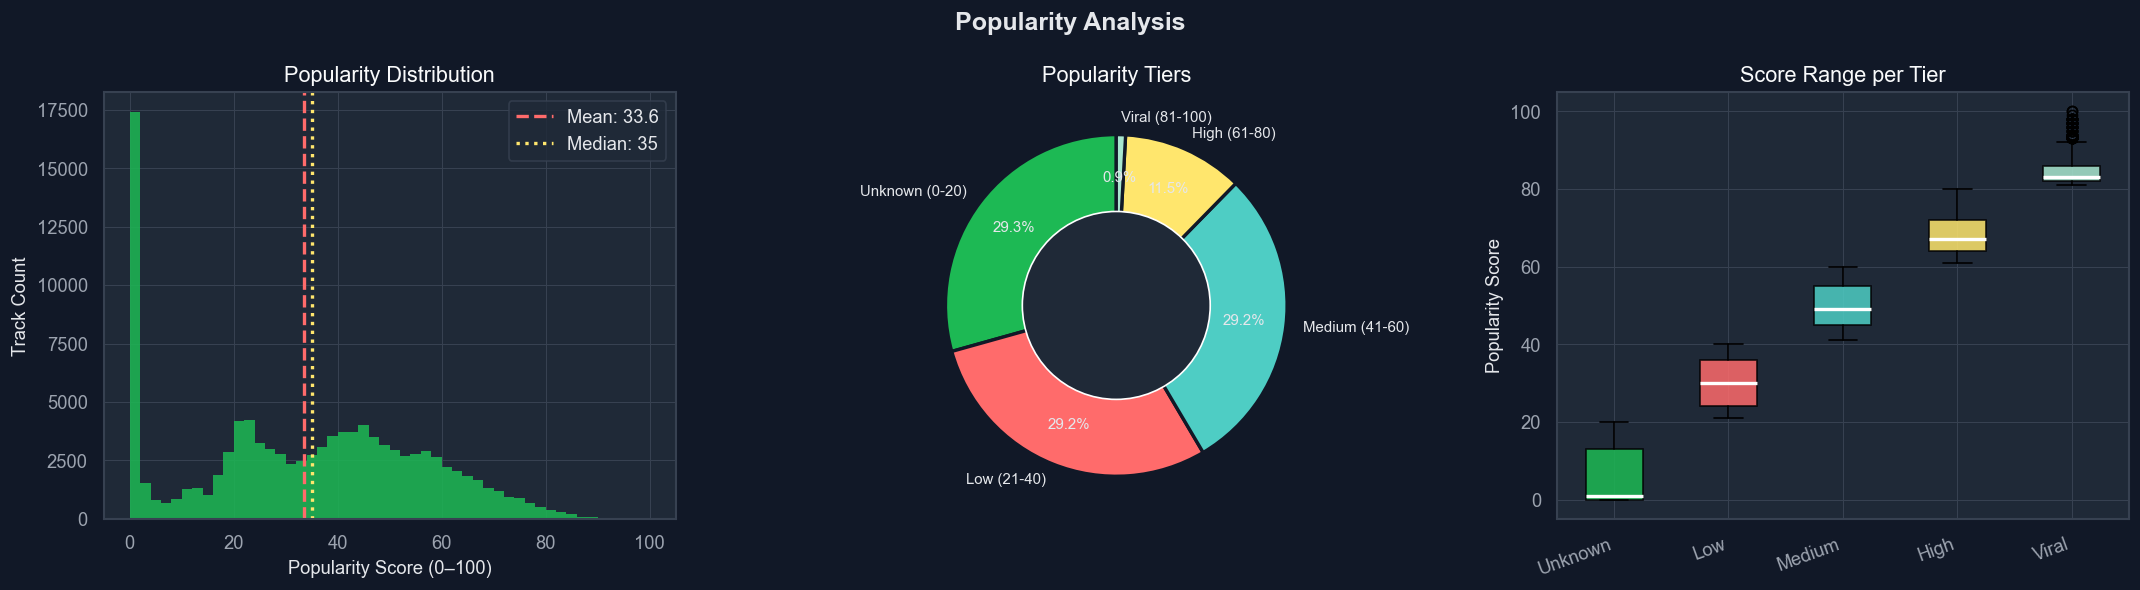

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Popularity Analysis', fontsize=15, fontweight='bold')

# Histogram
axes[0].hist(df['popularity'], bins=50, color=SPOTIFY_GREEN, alpha=0.85, edgecolor='none')
axes[0].axvline(df['popularity'].mean(),   color='#ff6b6b', lw=2, ls='--',
                label=f'Mean: {df["popularity"].mean():.1f}')
axes[0].axvline(df['popularity'].median(), color='#ffe66d', lw=2, ls=':',
                label=f'Median: {df["popularity"].median():.0f}')
axes[0].set_title('Popularity Distribution')
axes[0].set_xlabel('Popularity Score (0–100)')
axes[0].set_ylabel('Track Count')
axes[0].legend()

# Tier donut
tier_counts = df['popularity_tier'].value_counts().sort_index()
wedges, texts, autotexts = axes[1].pie(
    tier_counts.values, labels=tier_counts.index,
    autopct='%1.1f%%', colors=PALETTE[:len(tier_counts)],
    startangle=90, pctdistance=0.75,
    wedgeprops={'edgecolor': '#111827', 'linewidth': 2},
    textprops={'fontsize': 9}
)
# Donut hole
centre_circle = plt.Circle((0,0), 0.55, fc='#1f2937')
axes[1].add_artist(centre_circle)
axes[1].set_title('Popularity Tiers')

# Box plot by tier
tier_order = ['Unknown (0-20)','Low (21-40)','Medium (41-60)','High (61-80)','Viral (81-100)']
data_by_tier = [df[df['popularity_tier']==t]['popularity'].values for t in tier_order]
bp = axes[2].boxplot(data_by_tier, patch_artist=True,
                     medianprops={'color':'white','linewidth':2})
for patch, color in zip(bp['boxes'], PALETTE[:5]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
axes[2].set_xticklabels([t.split('(')[0].strip() for t in tier_order], rotation=20, ha='right')
axes[2].set_title('Score Range per Tier')
axes[2].set_ylabel('Popularity Score')

plt.tight_layout()
plt.savefig('plot1_popularity.png', bbox_inches='tight', dpi=130)
plt.show()

---
## 7. EDA — Genre Analysis <a id='7-genre'></a>

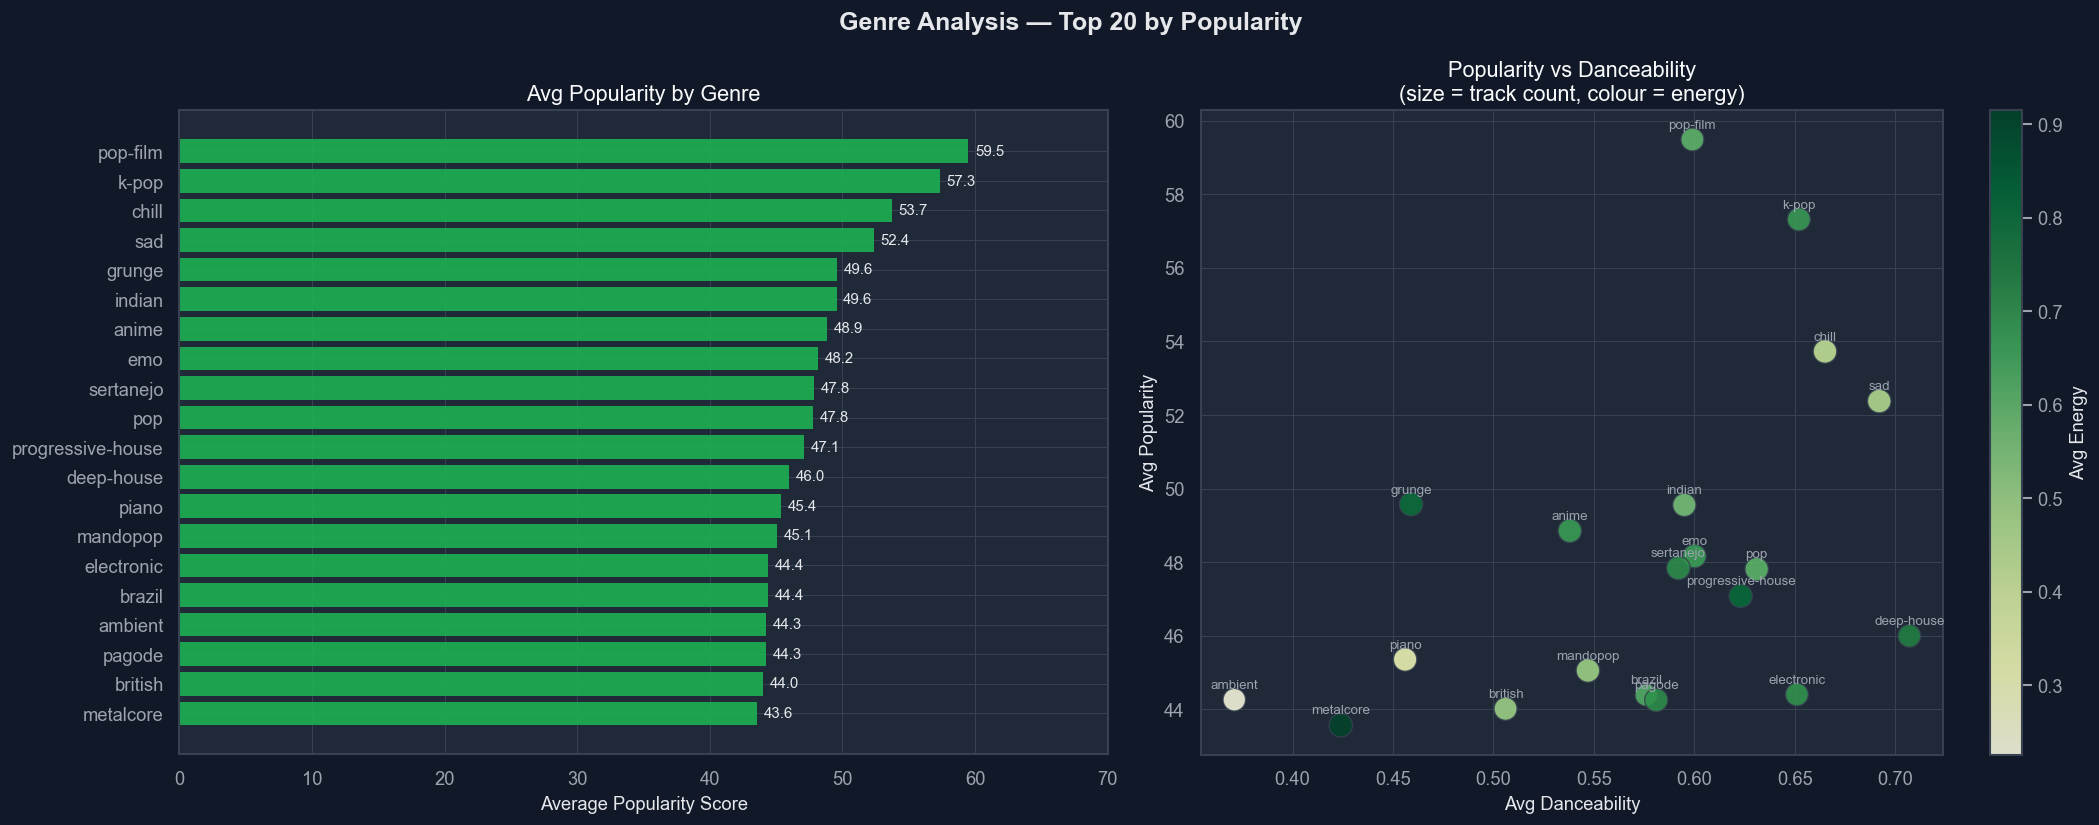

In [26]:
top_n = 20
top_genres_pop = genre_stats.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Genre Analysis — Top 20 by Popularity', fontsize=15, fontweight='bold')

# Horizontal bar — avg popularity
bars = axes[0].barh(top_genres_pop['track_genre'], top_genres_pop['avg_popularity'],
                    color=SPOTIFY_GREEN, alpha=0.85, edgecolor='none')
axes[0].set_title('Avg Popularity by Genre')
axes[0].set_xlabel('Average Popularity Score')
axes[0].set_xlim(0, 70)
for bar, val in zip(bars, top_genres_pop['avg_popularity']):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', color='#e5e7eb', fontsize=9)
axes[0].invert_yaxis()

# Bubble scatter — popularity vs danceability, sized by track_count
sc = axes[1].scatter(
    top_genres_pop['avg_danceability'],
    top_genres_pop['avg_popularity'],
    s=top_genres_pop['track_count'] * 0.2,
    c=top_genres_pop['avg_energy'],
    cmap='YlGn', alpha=0.85, edgecolors='#374151', linewidths=0.8
)
for _, row in top_genres_pop.iterrows():
    axes[1].annotate(row['track_genre'],
                     (row['avg_danceability'], row['avg_popularity']),
                     fontsize=8, color='#9ca3af', ha='center', va='bottom',
                     xytext=(0, 5), textcoords='offset points')
cbar = plt.colorbar(sc, ax=axes[1])
cbar.set_label('Avg Energy', color='#e5e7eb')
cbar.ax.yaxis.set_tick_params(color='#9ca3af')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#9ca3af')
axes[1].set_title('Popularity vs Danceability\n(size = track count, colour = energy)')
axes[1].set_xlabel('Avg Danceability')
axes[1].set_ylabel('Avg Popularity')

plt.tight_layout()
plt.savefig('plot2_genre_analysis.png', bbox_inches='tight', dpi=130)
plt.show()

---
## 8. EDA — Audio Feature Distributions <a id='8-features'></a>

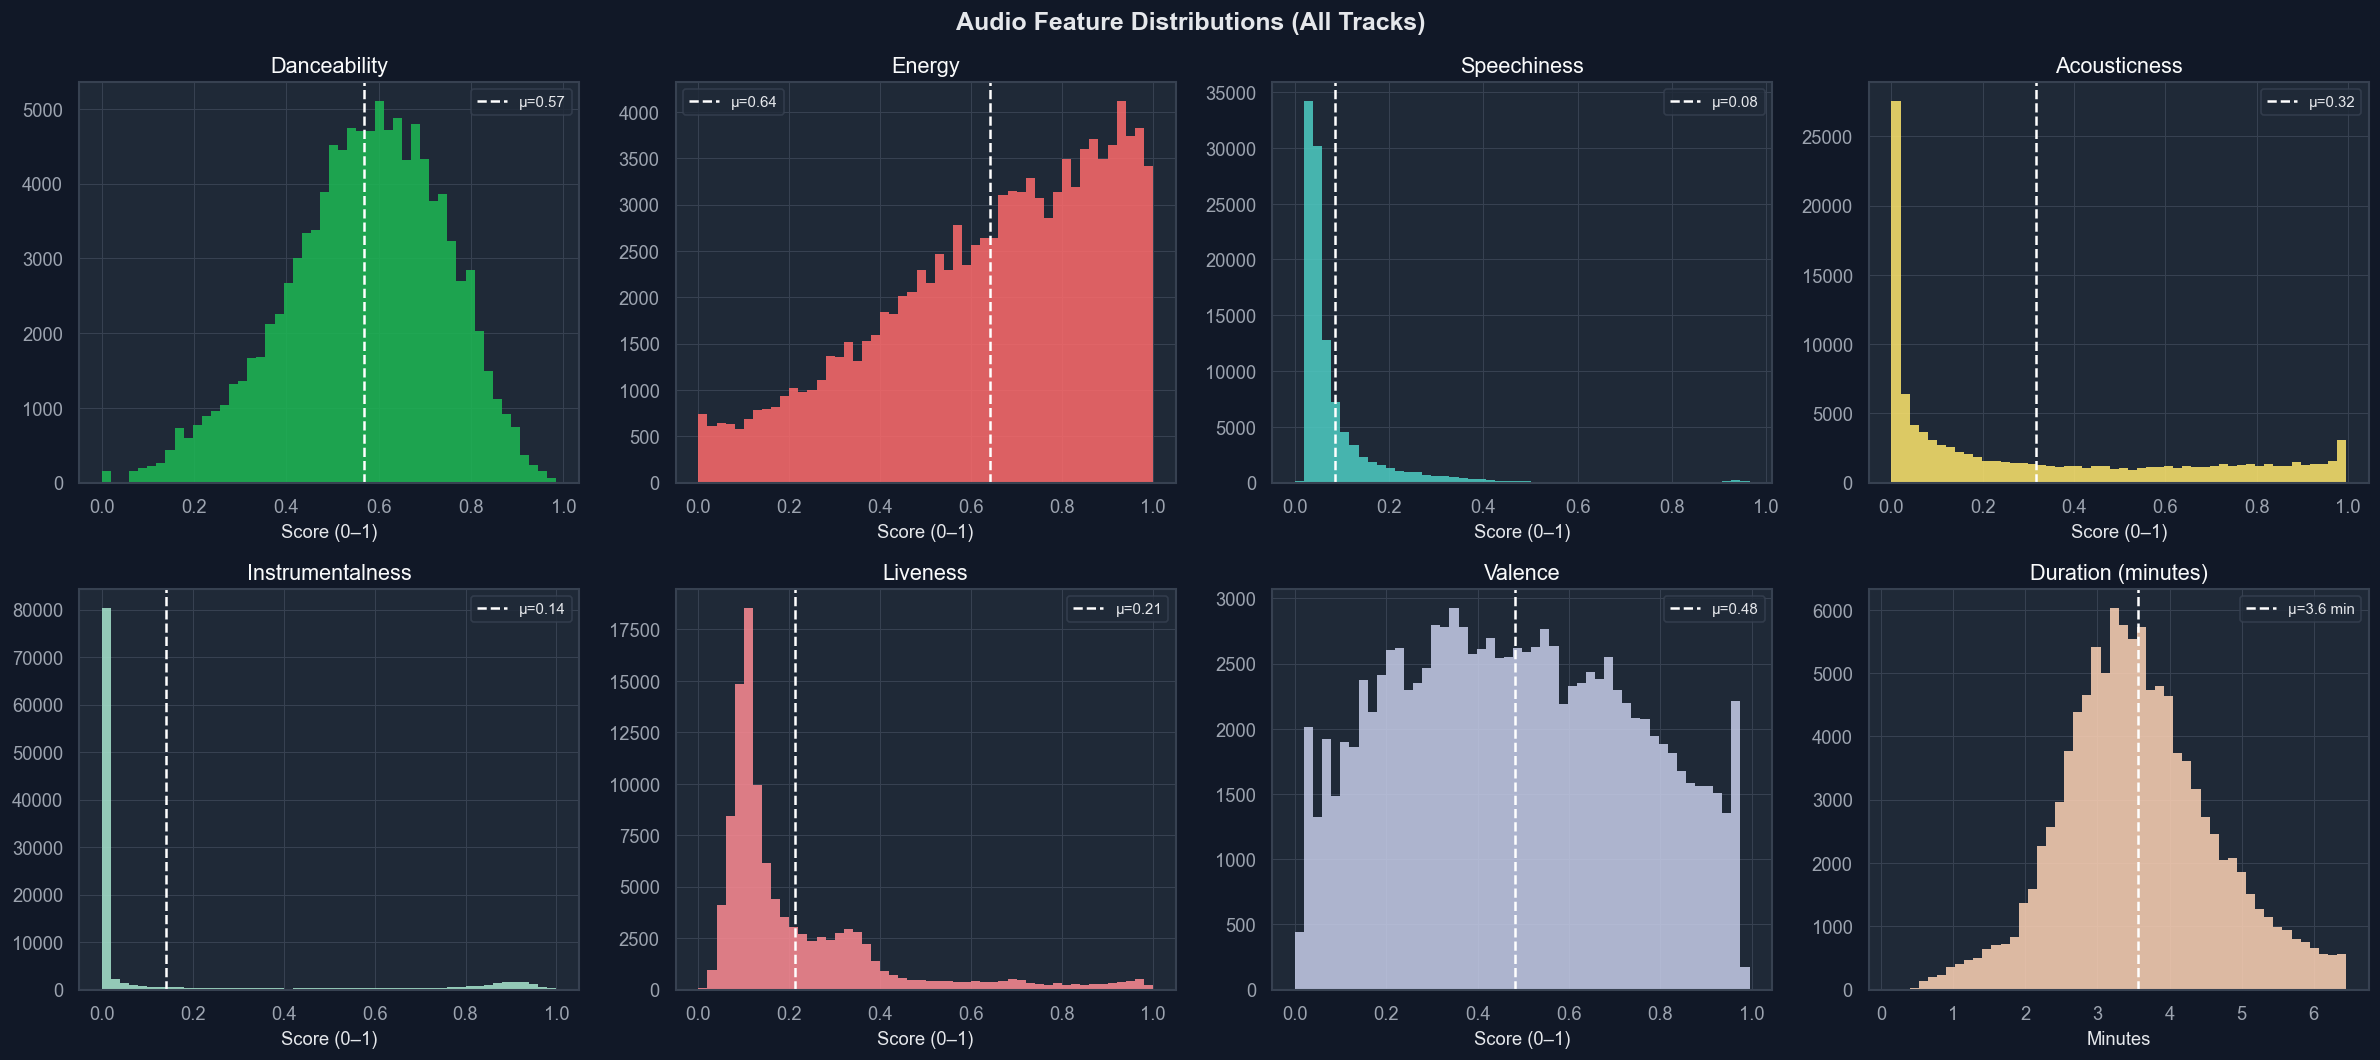

In [27]:
FEATURES = ['danceability','energy','speechiness','acousticness',
            'instrumentalness','liveness','valence']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Audio Feature Distributions (All Tracks)', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    axes[i].hist(df[feat], bins=50, color=PALETTE[i], alpha=0.85, edgecolor='none')
    axes[i].axvline(df[feat].mean(), color='white', lw=1.5, ls='--',
                    label=f'μ={df[feat].mean():.2f}')
    axes[i].set_title(feat.capitalize())
    axes[i].set_xlabel('Score (0–1)')
    axes[i].legend(fontsize=9)

# Duration in last subplot
axes[7].hist(df['duration_min'], bins=50, color=PALETTE[7], alpha=0.85, edgecolor='none')
axes[7].axvline(df['duration_min'].mean(), color='white', lw=1.5, ls='--',
                label=f'μ={df["duration_min"].mean():.1f} min')
axes[7].set_title('Duration (minutes)')
axes[7].set_xlabel('Minutes')
axes[7].legend(fontsize=9)

plt.tight_layout()
plt.savefig('plot3_audio_features.png', bbox_inches='tight', dpi=130)
plt.show()

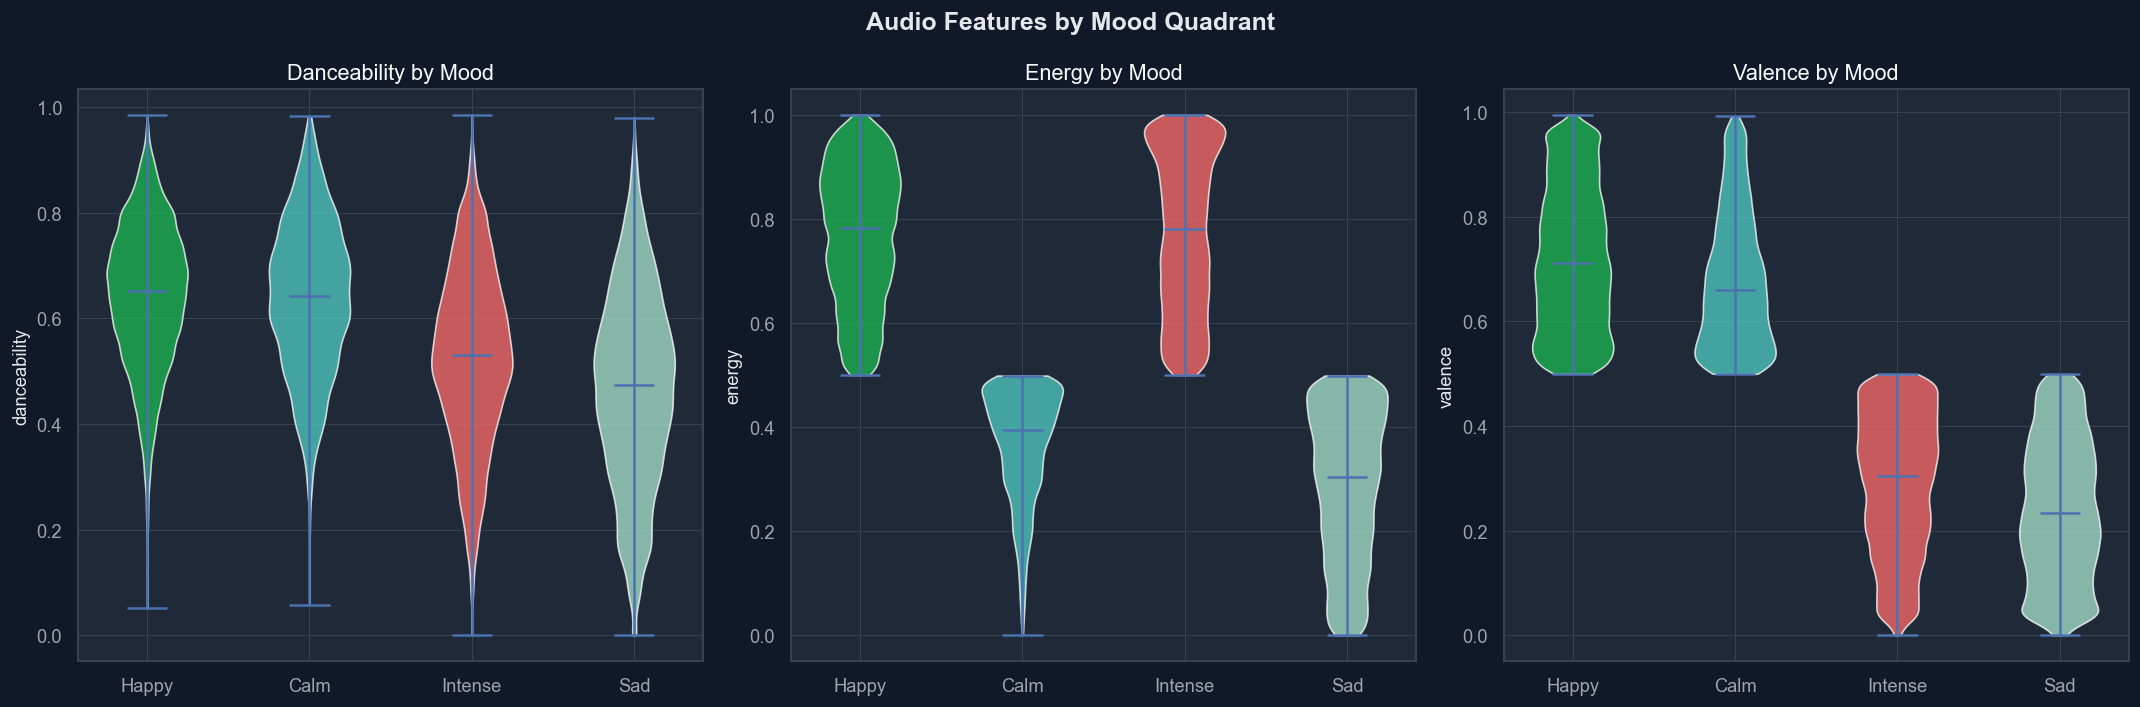

In [7]:
# Violin -- audio features split by mood
if 'plt' not in globals():
    import matplotlib.pyplot as plt

if 'df' not in globals():
    raise RuntimeError("df is not defined. Run the setup and dataset loading cells first.")

if 'mood' not in df.columns:
    def mood_label(row):
        if row['valence'] >= 0.5 and row['energy'] >= 0.5:
            return 'Happy'
        if row['valence'] >= 0.5 and row['energy'] < 0.5:
            return 'Calm'
        if row['valence'] < 0.5 and row['energy'] >= 0.5:
            return 'Intense'
        return 'Sad'

    df['mood'] = df.apply(mood_label, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Audio Features by Mood Quadrant', fontsize=15, fontweight='bold')

for i, feat in enumerate(['danceability', 'energy', 'valence']):
    mood_order = ['Happy', 'Calm', 'Intense', 'Sad']
    mood_colors = ['#1DB954', '#4ecdc4', '#ff6b6b', '#a8e6cf']
    parts = axes[i].violinplot(
        [df[df['mood'] == mood][feat].dropna().values for mood in mood_order],
        showmedians=True
    )
    for pc, color in zip(parts['bodies'], mood_colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.75)
    axes[i].set_xticks(range(1, 5))
    axes[i].set_xticklabels(mood_order)
    axes[i].set_title(f'{feat.capitalize()} by Mood')
    axes[i].set_ylabel(feat)

plt.tight_layout()
plt.savefig('plot4_mood_violin.png', bbox_inches='tight', dpi=130)
plt.show()

---
## 9. EDA — Correlation & Heatmap <a id='9-correlation'></a>

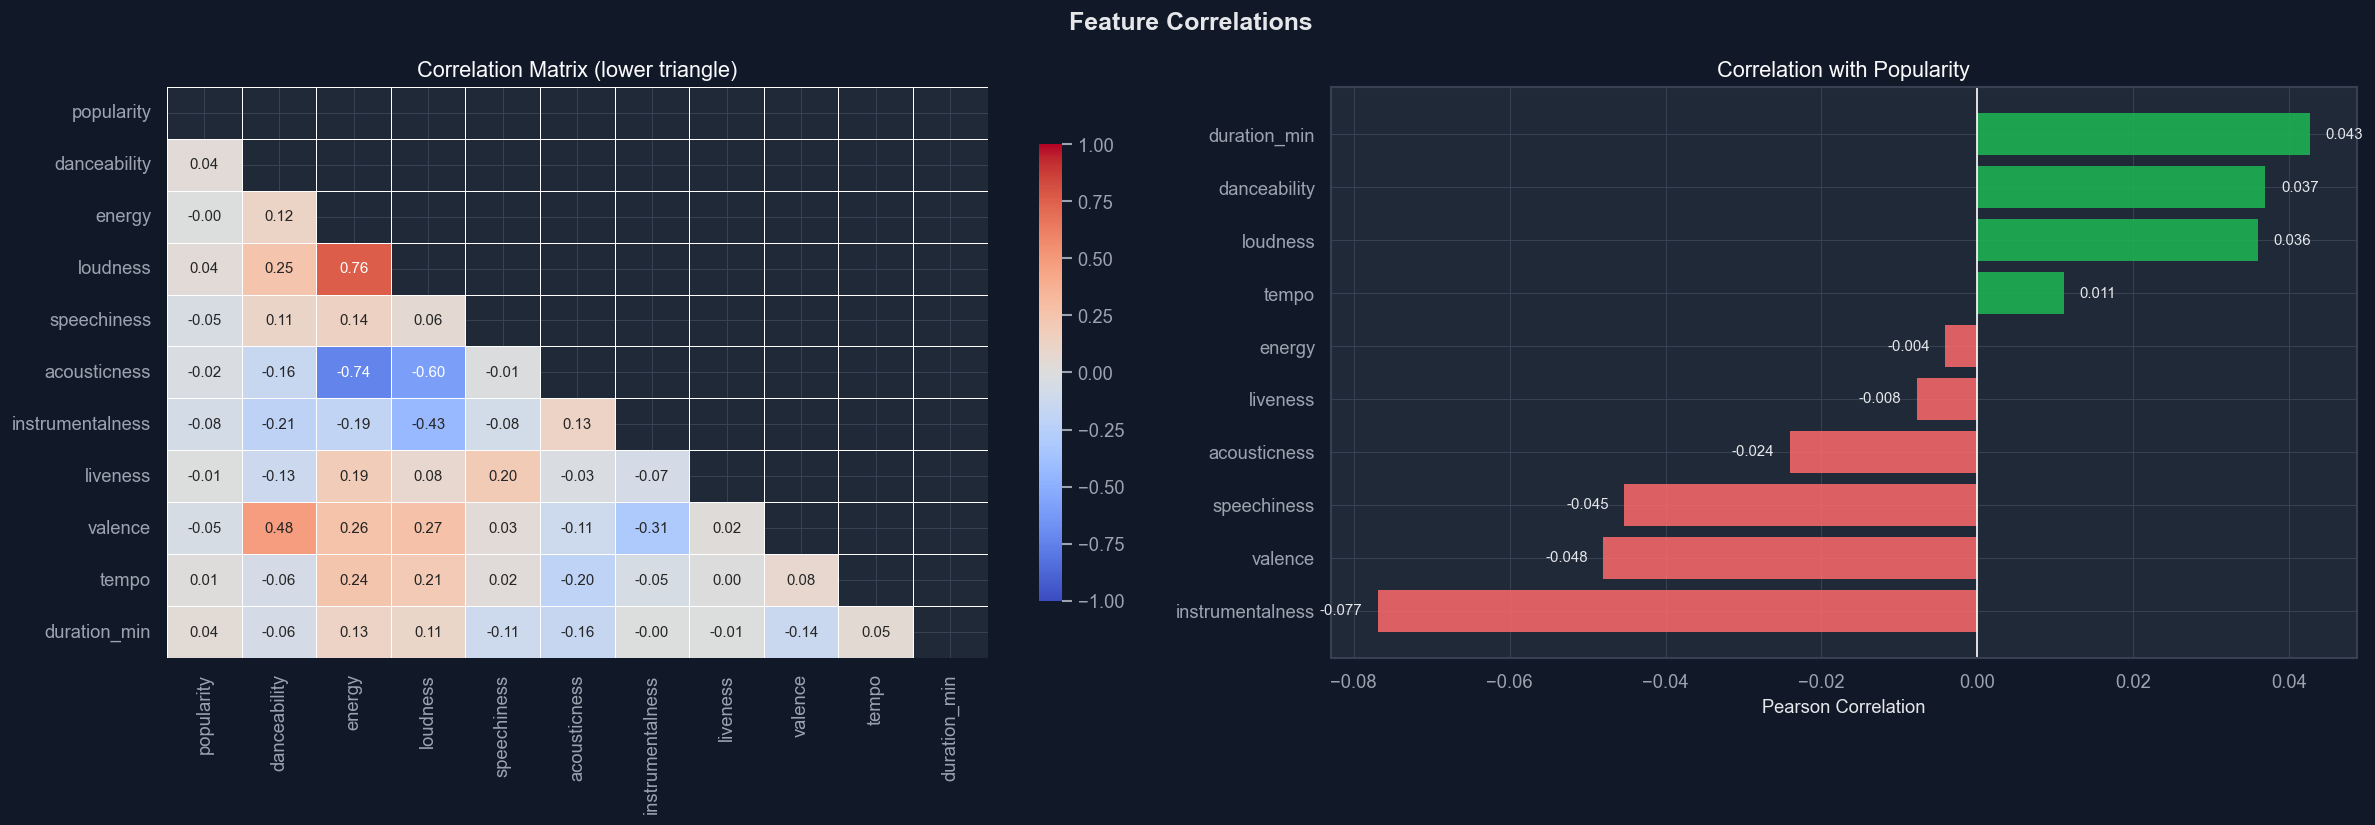

In [29]:
NUM_COLS = ['popularity','danceability','energy','loudness','speechiness',
            'acousticness','instrumentalness','liveness','valence','tempo','duration_min']

corr = df[NUM_COLS].corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Feature Correlations', fontsize=15, fontweight='bold')

# Full heatmap
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True   # upper triangle
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5, ax=axes[0], annot_kws={'size': 9},
    vmin=-1, vmax=1, cbar_kws={'shrink': 0.8}
)
axes[0].set_title('Correlation Matrix (lower triangle)')

# Popularity correlations bar chart
pop_corr = corr['popularity'].drop('popularity').sort_values()
colors = [SPOTIFY_GREEN if v > 0 else '#ff6b6b' for v in pop_corr.values]
axes[1].barh(pop_corr.index, pop_corr.values, color=colors, alpha=0.85, edgecolor='none')
axes[1].axvline(0, color='white', lw=1)
axes[1].set_title('Correlation with Popularity')
axes[1].set_xlabel('Pearson Correlation')
for i, (feat, val) in enumerate(pop_corr.items()):
    axes[1].text(val + (0.002 if val >= 0 else -0.002), i,
                 f'{val:.3f}', va='center',
                 ha='left' if val >= 0 else 'right',
                 color='#e5e7eb', fontsize=9)

plt.tight_layout()
plt.savefig('plot5_correlation.png', bbox_inches='tight', dpi=130)
plt.show()

---
## 10. EDA — Artist Analysis <a id='10-artists'></a>

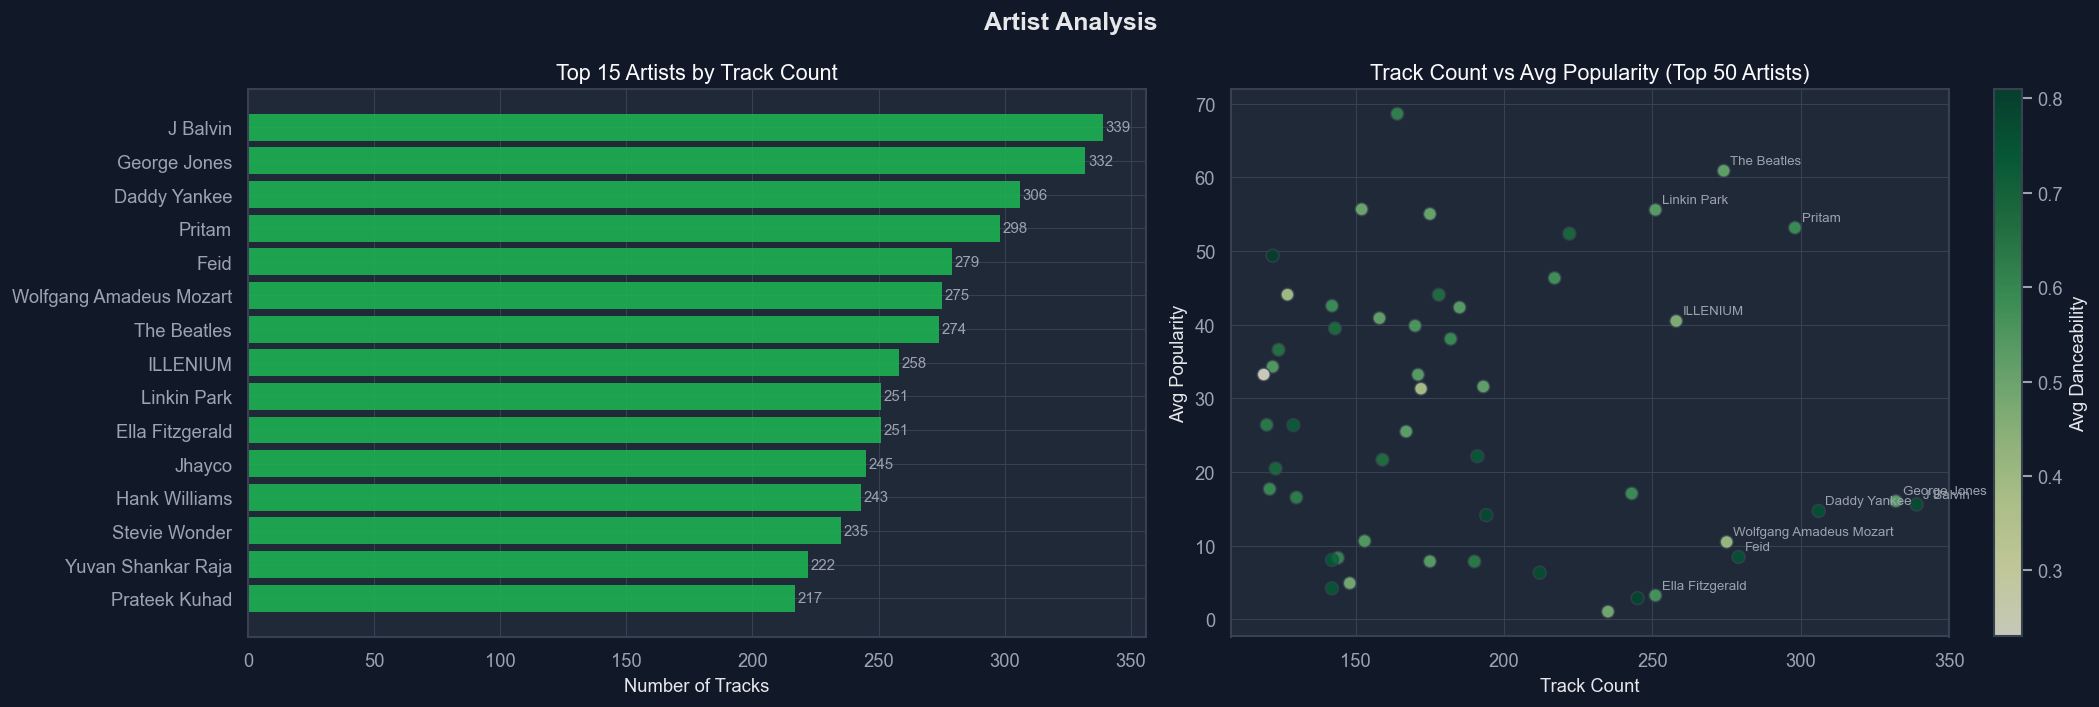

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Artist Analysis', fontsize=15, fontweight='bold')

# Top 15 by track count
top15 = top_artists.head(15)
bars = axes[0].barh(top15['primary_artist'], top15['track_count'],
                    color=SPOTIFY_GREEN, alpha=0.85, edgecolor='none')
axes[0].set_title('Top 15 Artists by Track Count')
axes[0].set_xlabel('Number of Tracks')
for bar in bars:
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.0f}', va='center', color='#9ca3af', fontsize=9)
axes[0].invert_yaxis()

# Scatter: track count vs avg popularity for top 50
sc = axes[1].scatter(
    top_artists['track_count'], top_artists['avg_popularity'],
    c=top_artists['avg_danceability'], cmap='YlGn',
    s=60, alpha=0.75, edgecolors='#374151'
)
# Label top 10
for _, row in top_artists.head(10).iterrows():
    axes[1].annotate(row['primary_artist'],
                     (row['track_count'], row['avg_popularity']),
                     fontsize=8, color='#9ca3af', xytext=(4, 4),
                     textcoords='offset points')
cbar = plt.colorbar(sc, ax=axes[1])
cbar.set_label('Avg Danceability', color='#e5e7eb')
cbar.ax.yaxis.set_tick_params(color='#9ca3af')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#9ca3af')
axes[1].set_title('Track Count vs Avg Popularity (Top 50 Artists)')
axes[1].set_xlabel('Track Count')
axes[1].set_ylabel('Avg Popularity')

plt.tight_layout()
plt.savefig('plot6_artists.png', bbox_inches='tight', dpi=130)
plt.show()

---
## 11. EDA — Tempo, Key & Mode <a id='11-musical'></a>

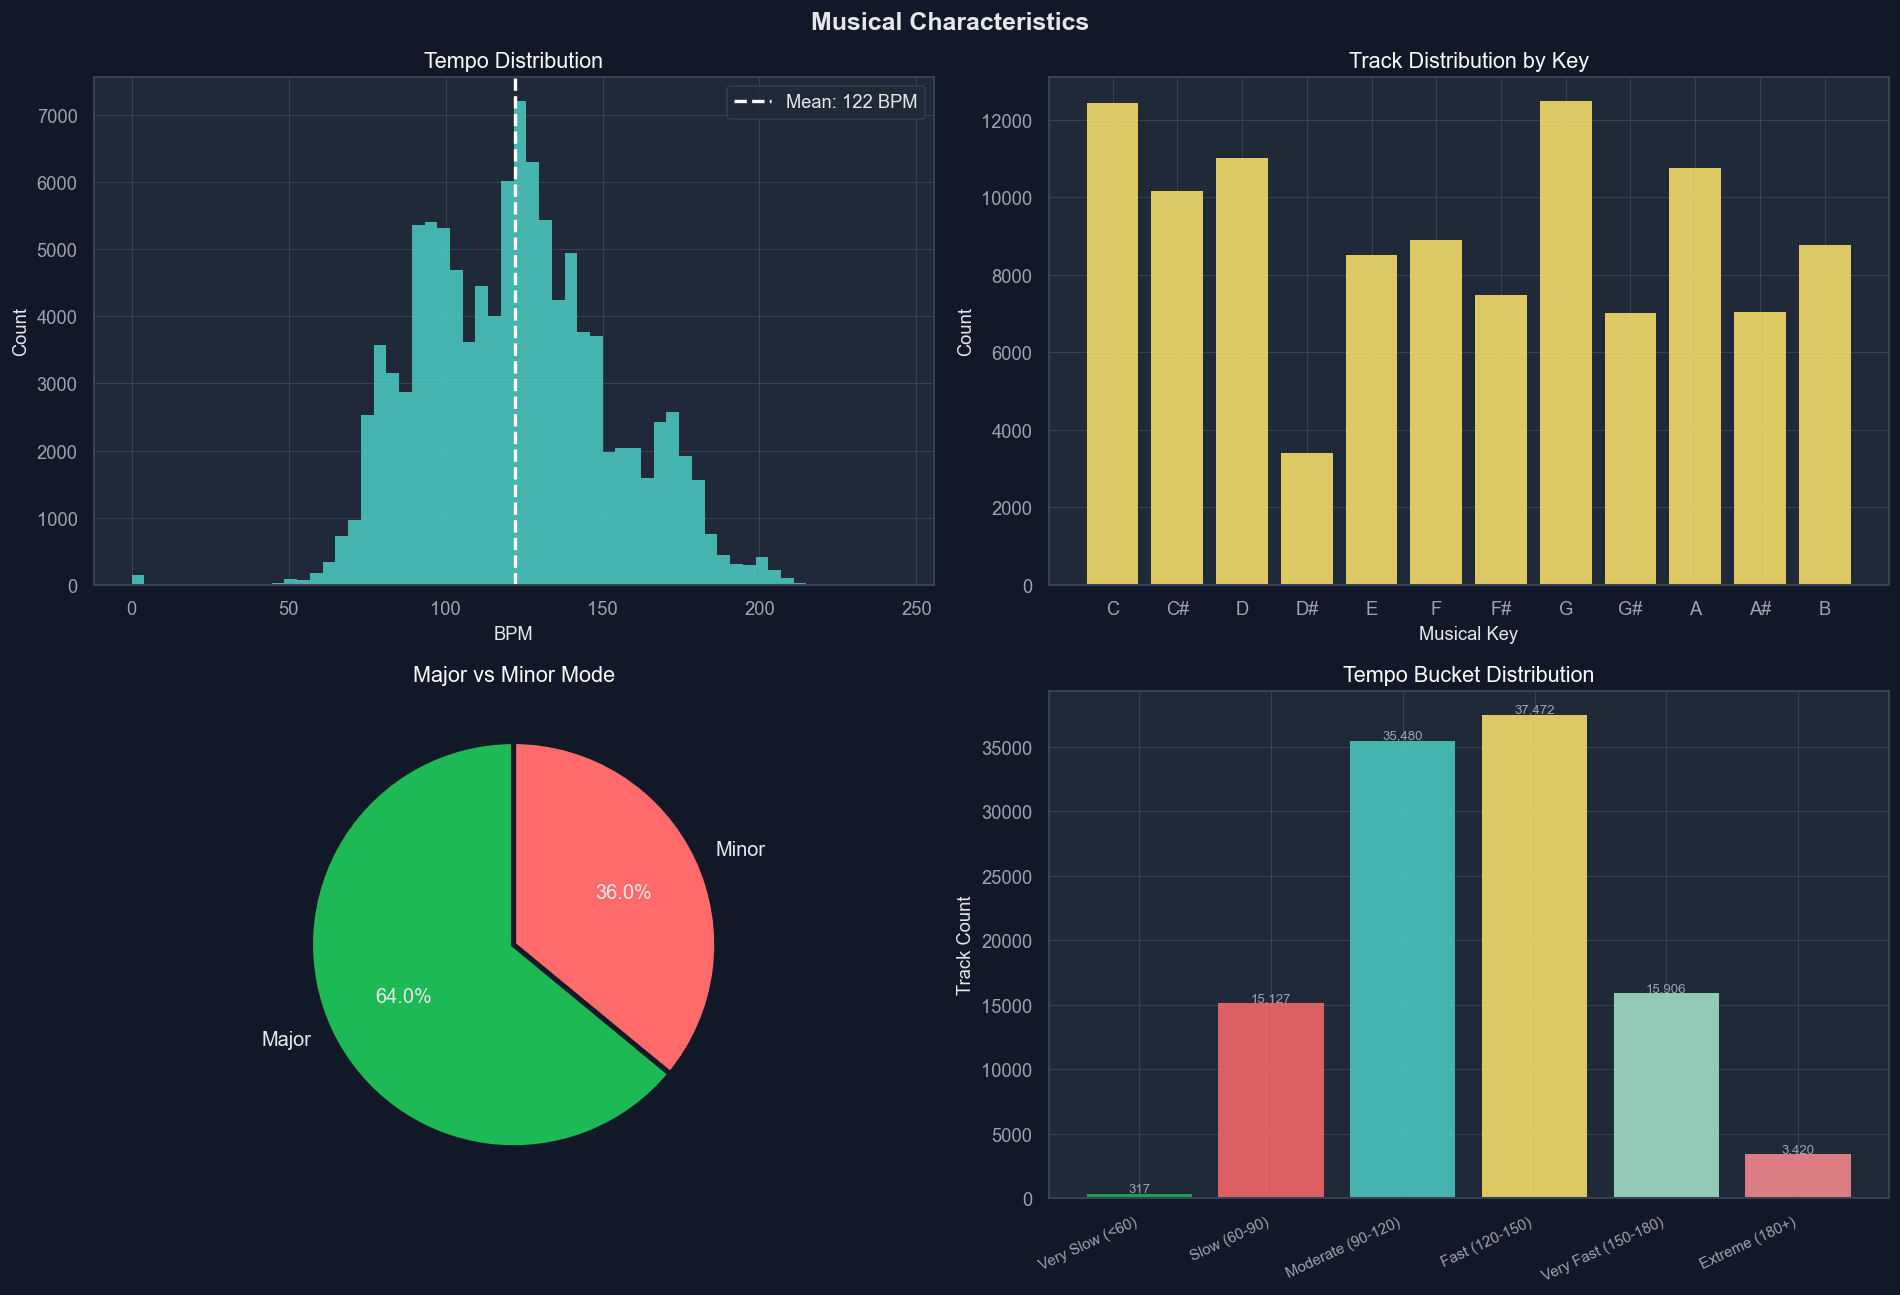

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Musical Characteristics', fontsize=15, fontweight='bold')

# Tempo distribution
axes[0,0].hist(df['tempo'], bins=60, color=PALETTE[2], alpha=0.85, edgecolor='none')
axes[0,0].axvline(df['tempo'].mean(), color='white', lw=2, ls='--',
                  label=f'Mean: {df["tempo"].mean():.0f} BPM')
axes[0,0].set_title('Tempo Distribution')
axes[0,0].set_xlabel('BPM')
axes[0,0].set_ylabel('Count')
axes[0,0].legend()

# Key distribution
key_counts = df['key_name'].value_counts()
key_order  = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']
key_vals   = [key_counts.get(k, 0) for k in key_order]
bars = axes[0,1].bar(key_order, key_vals, color=PALETTE[3], alpha=0.85, edgecolor='none')
axes[0,1].set_title('Track Distribution by Key')
axes[0,1].set_xlabel('Musical Key')
axes[0,1].set_ylabel('Count')

# Mode (Major vs Minor)
mode_counts = df['mode_name'].value_counts()
axes[1,0].pie(
    mode_counts.values, labels=mode_counts.index,
    autopct='%1.1f%%', colors=[SPOTIFY_GREEN, '#ff6b6b'],
    startangle=90, textprops={'fontsize': 12},
    wedgeprops={'edgecolor': '#111827', 'linewidth': 3}
)
axes[1,0].set_title('Major vs Minor Mode')

# Tempo bucket bar
tempo_counts = df['tempo_bucket'].value_counts().sort_index()
bars = axes[1,1].bar(range(len(tempo_counts)), tempo_counts.values,
                     color=PALETTE[:len(tempo_counts)], alpha=0.85, edgecolor='none')
axes[1,1].set_xticks(range(len(tempo_counts)))
axes[1,1].set_xticklabels([str(l) for l in tempo_counts.index], rotation=25, ha='right', fontsize=9)
axes[1,1].set_title('Tempo Bucket Distribution')
axes[1,1].set_ylabel('Track Count')
for bar in bars:
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                   f'{bar.get_height():,.0f}', ha='center', color='#9ca3af', fontsize=8)

plt.tight_layout()
plt.savefig('plot7_musical_features.png', bbox_inches='tight', dpi=130)
plt.show()

---
## 12. EDA — Explicit Content Analysis <a id='12-explicit'></a>

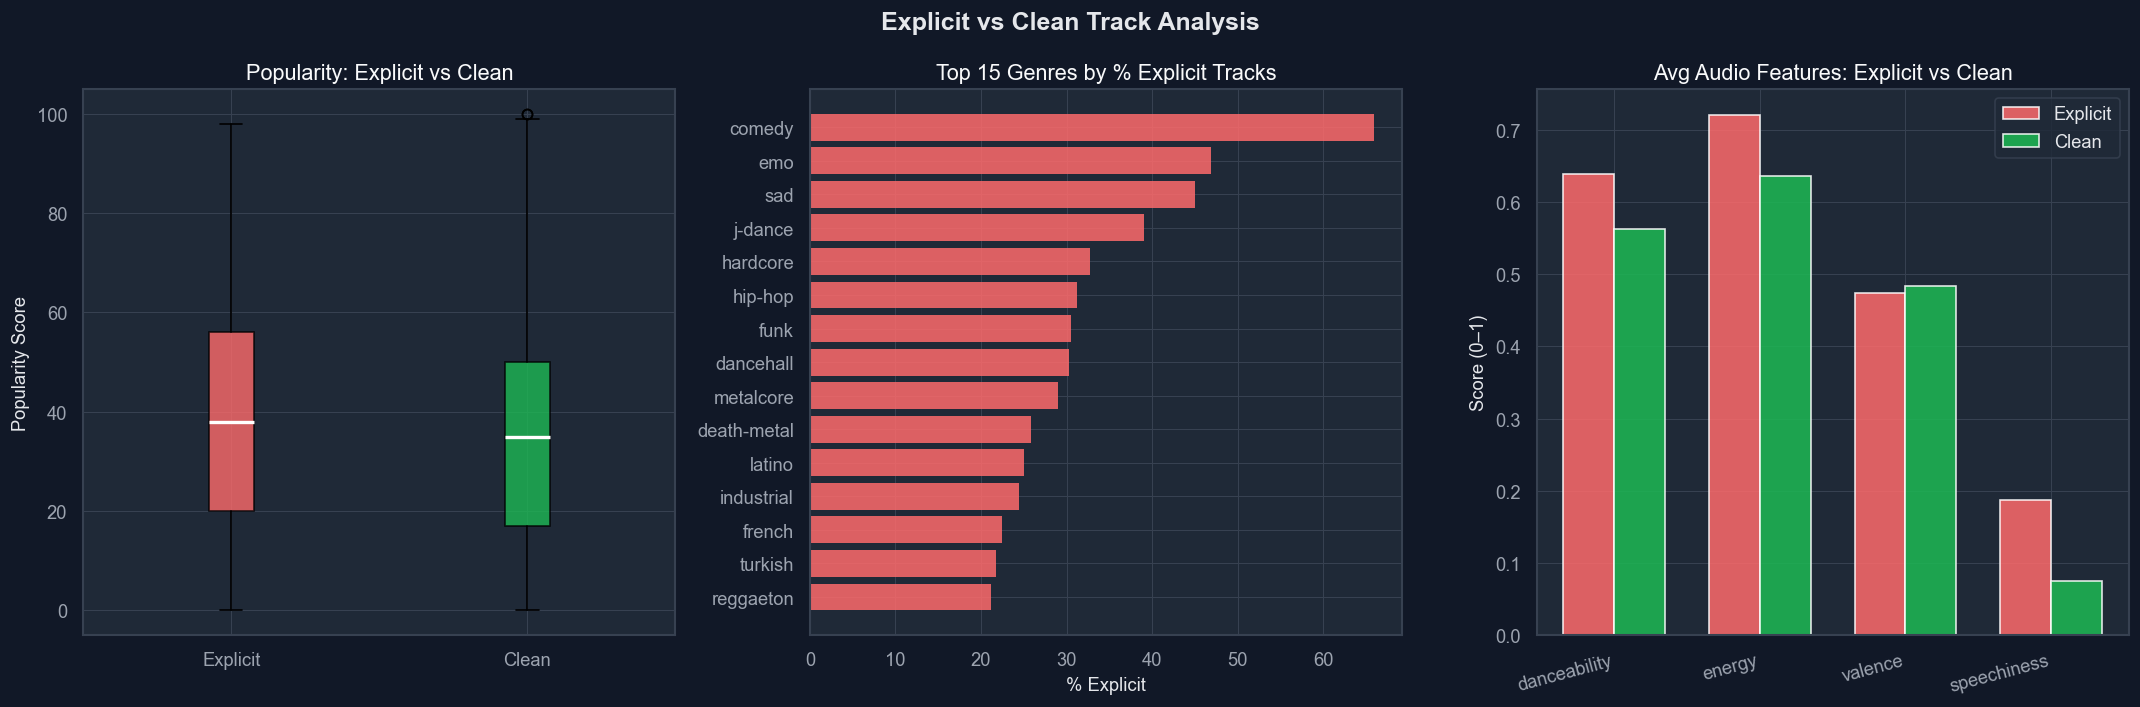

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Explicit vs Clean Track Analysis', fontsize=15, fontweight='bold')

# Box plot — popularity by explicit
exp_data = [df[df['explicit']==True]['popularity'].values,
            df[df['explicit']==False]['popularity'].values]
bp = axes[0].boxplot(exp_data, patch_artist=True,
                     medianprops={'color':'white','linewidth':2},
                     labels=['Explicit','Clean'])
bp['boxes'][0].set_facecolor('#ff6b6b'); bp['boxes'][0].set_alpha(0.8)
bp['boxes'][1].set_facecolor(SPOTIFY_GREEN); bp['boxes'][1].set_alpha(0.8)
axes[0].set_title('Popularity: Explicit vs Clean')
axes[0].set_ylabel('Popularity Score')

# Top 15 genres by % explicit
genre_explicit_pct = (
    df.groupby('track_genre')['explicit']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .head(15)
)
axes[1].barh(genre_explicit_pct.index, genre_explicit_pct.values,
             color='#ff6b6b', alpha=0.85, edgecolor='none')
axes[1].set_title('Top 15 Genres by % Explicit Tracks')
axes[1].set_xlabel('% Explicit')
axes[1].invert_yaxis()

# Audio features comparison
feats  = ['danceability','energy','valence','speechiness']
exp_means   = df[df['explicit']==True][feats].mean()
clean_means = df[df['explicit']==False][feats].mean()
x = np.arange(len(feats))
w = 0.35
axes[2].bar(x - w/2, exp_means.values,   w, label='Explicit', color='#ff6b6b', alpha=0.85)
axes[2].bar(x + w/2, clean_means.values, w, label='Clean',    color=SPOTIFY_GREEN, alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(feats, rotation=15, ha='right')
axes[2].set_title('Avg Audio Features: Explicit vs Clean')
axes[2].set_ylabel('Score (0–1)')
axes[2].legend()

plt.tight_layout()
plt.savefig('plot8_explicit.png', bbox_inches='tight', dpi=130)
plt.show()

---
## 13. Key Insights Summary <a id='13-insights'></a>

In [5]:
# ── Auto-compute all key metrics ──────────────────────────────────────────────
top_genre_pop    = genre_stats.iloc[0]
top_artist       = top_artists.iloc[0]
viral_count      = (df['popularity_tier'] == 'Viral (81-100)').sum()
pct_major        = (df['mode_name'] == 'Major').mean() * 100
pct_explicit     = df['explicit'].mean() * 100
exp_pop_diff     = (df[df['explicit']]['popularity'].mean() -
                    df[~df['explicit']]['popularity'].mean())
top_mood         = df['mood'].value_counts().index[0]
top_key          = df['key_name'].value_counts().index[0]
avg_duration     = df['duration_min'].mean()
highest_dance_genre = genre_stats.sort_values('avg_danceability', ascending=False).iloc[0]
most_instrumental   = genre_stats.sort_values('avg_acousticness', ascending=False).iloc[0]

print('=' * 60)
print('          🎵  SPOTIFY TRACKS — KEY INSIGHTS')
print('=' * 60)
print(f'  Total Tracks (cleaned)   : {len(df):>12,.0f}')
print(f'  Unique Artists           : {df["primary_artist"].nunique():>12,.0f}')
print(f'  Unique Genres            : {df["track_genre"].nunique():>12,.0f}')
print('-' * 60)
print('  POPULARITY')
print(f'  Mean Popularity Score    : {df["popularity"].mean():>12.1f}')
print(f'  Viral Tracks (>80)       : {viral_count:>12,.0f}  ({viral_count/len(df)*100:.1f}%)')
print(f'  Top Genre (popularity)   : {top_genre_pop["track_genre"]:>12}  (avg {top_genre_pop["avg_popularity"]:.1f})')
print('-' * 60)
print('  MUSIC FEATURES')
print(f'  Most Common Mood         : {top_mood:>12}')
print(f'  Most Common Key          : {top_key:>12}')
print(f'  % Major Key Tracks       : {pct_major:>11.1f}%')
print(f'  Avg Track Duration       : {avg_duration:>11.2f} min')
print(f'  Most Danceable Genre     : {highest_dance_genre["track_genre"]:>12}  ({highest_dance_genre["avg_danceability"]:.2f})')
print(f'  Most Acoustic Genre      : {most_instrumental["track_genre"]:>12}  ({most_instrumental["avg_acousticness"]:.2f})')
print('-' * 60)
print('  ARTISTS & CONTENT')
print(f'  Top Artist (# tracks)    : {top_artist["primary_artist"]:>12}  ({top_artist["track_count"]:.0f} tracks)')
print(f'  % Explicit Tracks        : {pct_explicit:>11.1f}%')
print(f'  Explicit Popularity Diff : {exp_pop_diff:>+11.2f} points vs clean')
print('=' * 60)

NameError: name 'genre_stats' is not defined

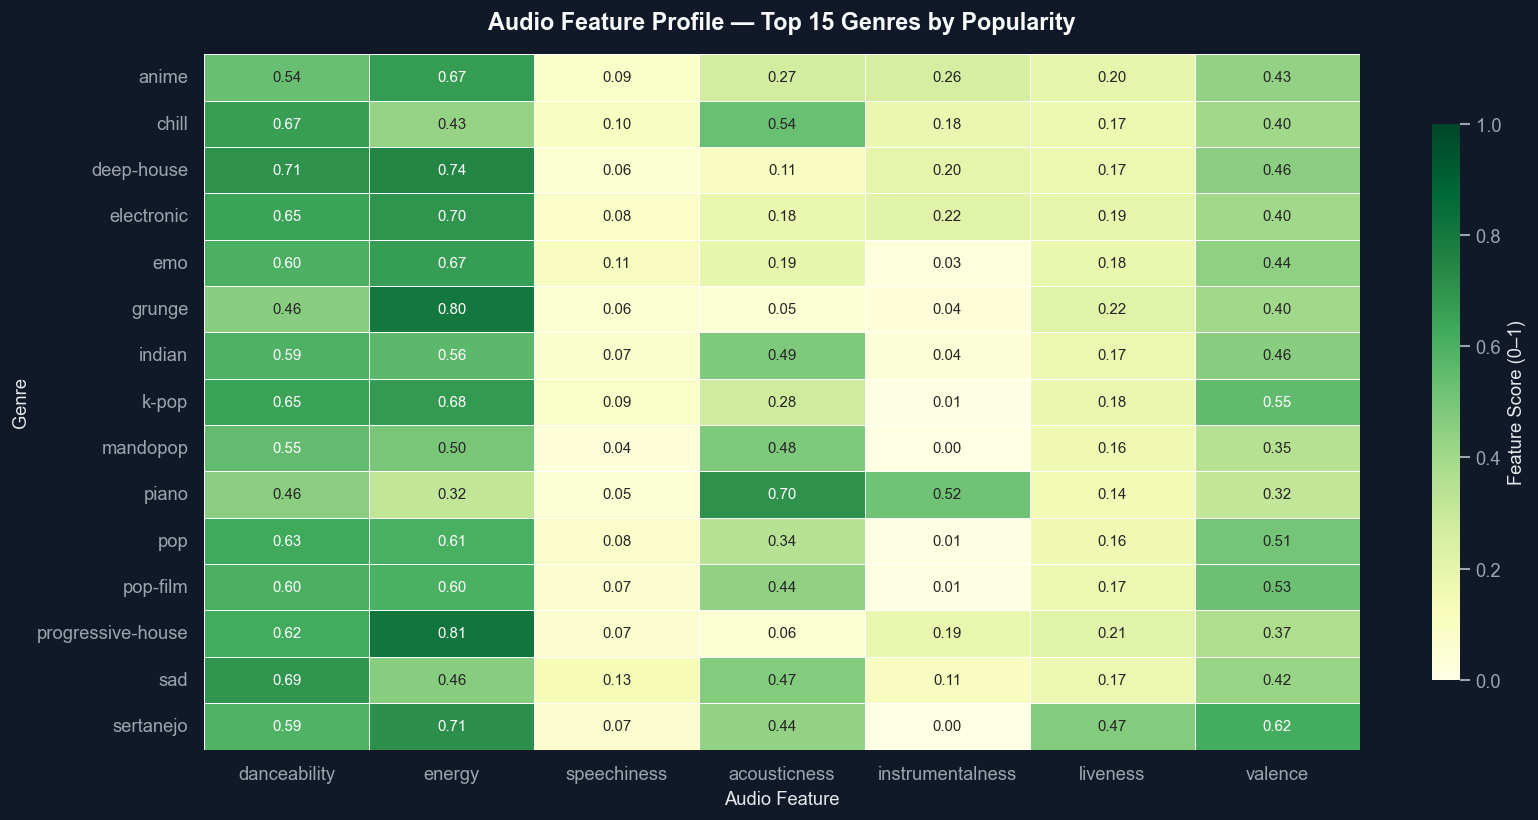


✅ All 9 charts saved!
✅ All 8 Power BI CSV tables saved!

Next step: Import pbi_*.csv files into Power BI Desktop


In [34]:
# ── Summary heatmap — audio features across top 15 genres ────────────────────
top15_genres = genre_stats.head(15)['track_genre'].tolist()
heat_df = audio_by_genre[audio_by_genre['track_genre'].isin(top15_genres)]\
            .set_index('track_genre')[AUDIO_FEATURES]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    heat_df, annot=True, fmt='.2f', cmap='YlGn',
    linewidths=0.5, ax=ax, annot_kws={'size': 9},
    vmin=0, vmax=1, cbar_kws={'label': 'Feature Score (0–1)', 'shrink': 0.8}
)
ax.set_title('Audio Feature Profile — Top 15 Genres by Popularity',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Audio Feature')
ax.set_ylabel('Genre')
plt.tight_layout()
plt.savefig('plot9_genre_feature_heatmap.png', bbox_inches='tight', dpi=130)
plt.show()

print('\n✅ All 9 charts saved!')
print('✅ All 8 Power BI CSV tables saved!')
print('\nNext step: Import pbi_*.csv files into Power BI Desktop')